In [21]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [22]:
loan=pd.read_csv("7.13_loan_approval_data.csv")

In [23]:
loan.head(5)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [24]:
loan.info()
loan["Loan_Approved"].head(2)

loan = loan.dropna(subset=["Loan_Approved"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [25]:
x=loan.drop("Loan_Approved",axis=1)
y=loan["Loan_Approved"]

y=y.map({"Yes":1,"No":0})

In [26]:
x=pd.get_dummies(x,columns=["Employment_Status","Loan_Purpose","Property_Area","Education_Level","Gender","Employer_Category","Marital_Status"],drop_first=True)

In [27]:
x.fillna(0, inplace=True)


In [28]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.3,random_state=42)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)   # Fit only on training data
x_test_scaled = scaler.transform(x_test)    


In [29]:
model=LogisticRegression()
model.fit(x_train_scaled,y_train)

y_pred=model.predict(x_test_scaled)

In [30]:
print("Accuracy_score:",accuracy_score(y_test,y_pred))

Accuracy_score: 0.7473684210526316


In [31]:
print(confusion_matrix(y_test,y_pred))

[[170  25]
 [ 47  43]]


In [32]:
import seaborn as sns

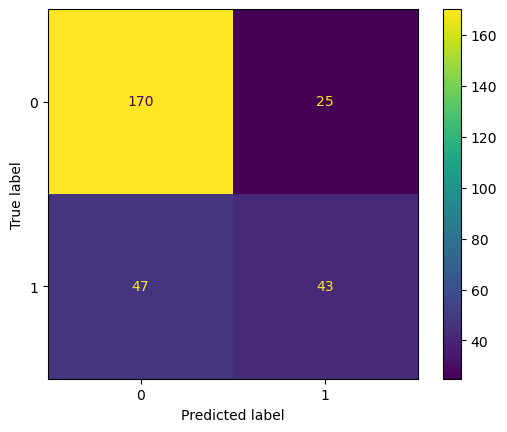

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()
